In [9]:
import numpy as np
import scipy.integrate as integ
import scipy.special as sf
import scipy.interpolate as interp
import math
import matplotlib.pyplot as plt
import pandas as pd
import pathlib
import re

import matplotlib as mpl
mpl.rc('xtick', direction='in', top=True)
mpl.rc('ytick', direction='in', right=True)
mpl.rc('xtick.minor', visible=True)
mpl.rc('ytick.minor', visible=True)

rng = np.random.default_rng()

In [2]:
def is_homeomorphic(p, q1, q2):
    """
    Test the homeomorphic condition for Lens spaces L(p, q1) and L(p, q2).
    Returns True or False.
    """
    return (q1 == q2%p) or (q1 == (-q2%p)) or ((q1*q2)%p == 1) \
            or ((q1*q2)%p == (-1)%p)

def get_unique(p):
    qlist = []
    for q2 in range(2, p//2+1):
        # p and q2 must be relatively prime
        if math.gcd(p, q2) != 1:
            continue
        for q1 in qlist:
            if is_homeomorphic(p, q1, q2):
                break
        else: # One of the oddest features in Python!
            qlist.append(q2)
    return qlist

In [3]:
def clone_separations(p, q, s):
    """
    Calculate all clone separations for L(p,q) given the parameter s.
    Inputs:
      p, q: integers: parameters of the lens space L(p,q).
      s: 1d array of size N: parameter determining the location of points in S^3
          This must be an array and the values must be in [0, 1].
    Outputs:
      distances: N x p-1 array: 2d array of clone distances.
             Stored in the order shown: 
                 First axis is the parameter number from the original array.
                 Second axis is the clone number, there are p-1 clones.     
    """
    cos = np.cos(2*np.pi * np.arange(1, p) / p)
    cosq = np.cos(2*np.pi * np.arange(1, p) * q / p)
    cosangs = s[:, np.newaxis] * cos[np.newaxis, :] + (1 - s)[:, np.newaxis] * cosq[np.newaxis, :]
    return np.arccos(cosangs)

In [4]:
def do_dmax_iteration(p, q, smin, smax, Nsteps=1000):
    s = np.linspace(smin, smax, Nsteps)
    dmin = clone_separations(p, q, s).min(axis=-1)
    dmax = dmin.max()
    indmax = dmin.argmax()
    return s[indmax-1], s[indmax+1], dmax

In [5]:
def find_dmax(p, q, maxiter=10, tol=1e-7, Nsteps=100):
    dmax = -1
    dmaxprev = 1
    smin, smax = 0.0, 1.0
    niter = 0
    while niter <= maxiter and not np.allclose(dmax, dmaxprev, rtol=tol, atol=tol):
        dmaxprev = dmax
        smin, smax, dmax = do_dmax_iteration(p, q, smin, smax, Nsteps=Nsteps)
        niter += 1
    return dmax, niter

In [12]:
pmax = 2200
lens_distance_file2 = pathlib.Path(f'lens_distances_{pmax}_pq.hdf5')
if lens_distance_file2.exists():
    df2 = pd.read_hdf(lens_distance_file2, 'clonedistances')
else:
    res = []
    nitermax = -1
    for p in range(5, pmax+1):
        for q in get_unique(p):
            dmax, niter = find_dmax(p, q, Nsteps=100)
            if niter > nitermax:
                nitermax = niter
            if niter >= 10:
                print(f"Failed for {p}, {q}")
            res.append({'p': p, 'q': q, 'dmax': dmax})
    df2 = pd.DataFrame.from_dict(res)
    df2.to_hdf(lens_distance_file2, key='clonedistances')

## $d_{\mathrm{LSS}}$

The observer distance is defined as
$$\chi(z) = \sqrt{|-\Omega_K|} \int_{0}^{z} \frac{\mathrm{d}z}{\sqrt{\Omega_m (1+z)^3 + \Omega_K (1+z)^2 + \Omega_\Lambda}}, $$
where $\Omega_m + \Omega_K + \Omega_\Lambda = 1$.

With this the distance to last scattering is
$$ d_{\mathrm{LSS}} = 2 \chi(z_{\mathrm{LS}}). $$
We will choose $z_{\mathrm{LS}} = 1090$

In [13]:
def Einv(z, Om, OK, OL):
    zp1 = 1 + z
    return 1 / np.sqrt(Om * zp1**3 + OK * zp1**2 + OL)

def chi(z, Om, OK, OL):
    return np.sqrt(np.abs(-OK)) * integ.quad(Einv, 0, z, args=(Om, OK, OL))[0]

## Planck 2018

[Planck 2018 Results](https://www.aanda.org/articles/aa/full_html/2020/09/aa33910-18/aa33910-18.html#F29) shows contours for $\Omega_m$ versus $\Omega_K$. Extracting some points we have the following.

poly1d([-3.71224512,  0.3140533 ])

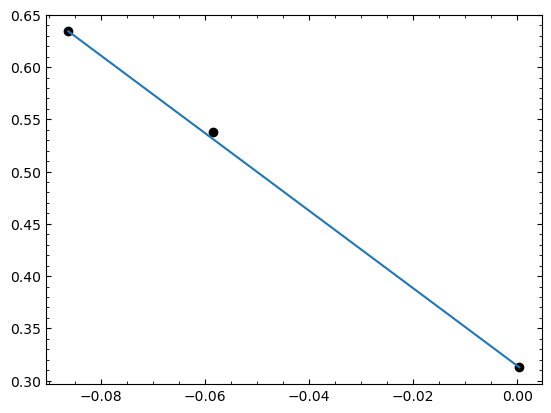

In [14]:
planck_data_OK = np.array([0.0003766478342749624, -0.05856873822975517, -0.08625235404896422])
planck_data_Om = np.array([0.31265508684863513, 0.5382133995037219, 0.63424317617866])
plt.plot(planck_data_OK, planck_data_Om, 'ko')
approx = interp.lagrange(planck_data_OK[[0,-1]], planck_data_Om[[0, -1]])
plt.plot(planck_data_OK[[0,-1]], planck_data_Om[[0, -1]])
approx

From this we derive
$$ \Omega_m \approx 0.314 - 3.71 \Omega_K. $$

### $d_{\mathrm{LSS}}$ vs $\Omega_K$

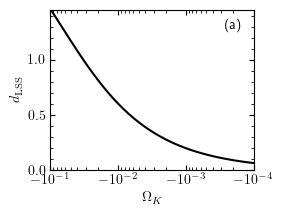

In [15]:
zLS = 1090
# Reverse order for plotting purposes
OK = - np.logspace(-4, -1, 40)[::-1]
Om = 0.314 - 3.71 * OK
OL = 1 - Om - OK

dLSS = 2 * np.sqrt(np.abs(-OK)) * integ.quad_vec(Einv, 0, zLS, args=(Om, OK, OL))[0]

figwidth = 3 # inches

plt.rcParams.update({"text.usetex": True})
# fig = plt.figure(figsize=(4, 8/3))
fig = plt.figure()
(w, h) = fig.get_size_inches()
fig.set_size_inches(figwidth, h * figwidth / w)
ax = fig.add_subplot(111)
ax.plot(np.abs(OK), dLSS, 'k-')
ax.set_xscale('log')
# Make labels nice, by hand
newlab = []
for lab in ax.xaxis.get_ticklabels():
    txt = re.sub('10\\^', '-10^', lab.get_text())
    lab.set_text(txt)
    newlab.append(lab)
ax.xaxis.set_ticks(ax.xaxis.get_ticklocs(), labels=newlab)
ax.set_xlim(np.abs(OK[0]), np.abs(OK[-1]))
ax.set_ylim(0, 1.45)
ax.set_xlabel(r'$\Omega_K$')
ax.set_ylabel(r'$d_{\mathrm{LSS}}$')
ax.text(0.9, 0.9, '(a)', ha='center', va='center', transform=ax.transAxes)
fig.tight_layout()
fig.savefig('dLSSvsOmegaK.pdf')
plt.rcParams.update({"text.usetex": False})

### $p^*$ vs $\Omega_K$

Using the above and our limit on $p$ we can create an exclusion region plot.

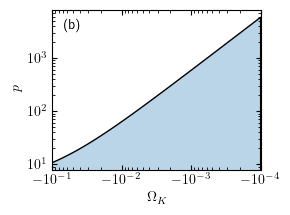

In [16]:
alpha = 0.761
pstar = (2 * np.pi * alpha / dLSS)**2
figwidth = 3 # inches

plt.rcParams.update({"text.usetex": True})
fig = plt.figure()
(w, h) = fig.get_size_inches()
fig.set_size_inches(figwidth, h * figwidth / w)
ax = fig.add_subplot(111)
ax.fill_between(np.abs(OK), pstar, ec='k', ls='-', fc=('C0', 0.3))
ax.set_xscale('log')
ax.set_yscale('log')
# Make labels nice, by hand
newlab = []
for lab in ax.xaxis.get_ticklabels():
    txt = re.sub('10\\^', '-10^', lab.get_text())
    lab.set_text(txt)
    newlab.append(lab)
ax.xaxis.set_ticks(ax.xaxis.get_ticklocs(), labels=newlab)
ax.set_xlim(np.abs(OK[0]), np.abs(OK[-1]))
ax.set_xlabel(r'$\Omega_K$')
ax.set_ylabel(r'$p$')
ax.text(0.1, 0.9, '(b)', ha='center', va='center', transform=ax.transAxes)
fig.tight_layout()
fig.savefig('pvsOmegaK.pdf')
plt.rcParams.update({"text.usetex": False})

### $p$-$q$ plane

Inverting to find $\Omega_K$ as a function of $\Omega_m$ we can make a plot of $p$ and $q$.

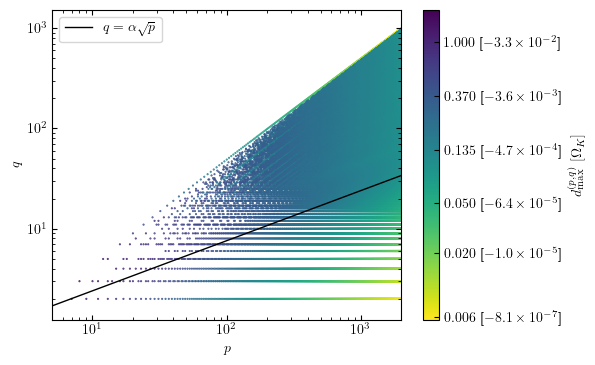

In [17]:
# Since we reversed OK above, we must reverse it back to interpolate ....
OmegaK_spline = interp.InterpolatedUnivariateSpline(dLSS[::-1], OK[::-1])
alpha = 0.761
pmax = 2200
ind = df2['p'] <= pmax
dfsort = df2[ind].sort_values(by='dmax')

ind = dfsort['p'] <= pmax

# To make the labels look nicer we can (sometimes) convert them to scientific notation.
def number_to_scientific_latex(x, mantisafmt='g'):
    exponent = np.floor(np.log10(np.abs(x))).astype(int)
    mantisa = x / 10.**exponent
    return rf'${mantisa:{mantisafmt}}\times 10^{{{exponent}}}$'
    
plt.rcParams.update({"text.usetex": True})
fig = plt.figure(figsize=(6, 3.75))
ax = fig.add_subplot(111)
# Use a logarithmic color bar scaling
sc = ax.scatter(dfsort['p'][ind], dfsort['q'][ind], marker='.',
                c=np.log(dfsort['dmax'][ind]),
                s=1,
                cmap='viridis_r',
                rasterized=True,
               )
cb = fig.colorbar(sc)
# Set ticks by hand
tick_loc = np.array([6e-3, 2e-2, 5e-2, 0.135, 0.37, 1])
tick_labels = [f'${x:.3f}$ [{number_to_scientific_latex(OmegaK_spline(x), mantisafmt=".1f")}]' for x in tick_loc]
cb.set_ticks(np.log(tick_loc), labels=tick_labels)
cb.minorticks_off()
cb.set_label(r'$d^{(p,q)}_{\mathrm{max}}\; [\Omega_K]$')
ax.set_xlabel('$p$')
ax.set_ylabel('$q$')
parr = np.arange(5, pmax+1)
ax.plot(parr, alpha * np.sqrt(parr), 'k-', lw=1, label=r'$q = \alpha \sqrt{p}$')
ax.set_xlim(parr[0], pmax-200)
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
fig.tight_layout()
fig.savefig('distance_pq.pdf', dpi=300)
plt.rcParams.update({"text.usetex": False})